   Student_ID    Name  Math  Science  English
0           1    Neha    76       74       47
1           2   Sneha    54       60       70
2           3   Pooja    64       78       55
3           4  Anjali    43       98       74
4           5   Rahul    88       56       67
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Student_ID  20 non-null     int64
 1   Name        20 non-null     str  
 2   Math        20 non-null     int64
 3   Science     20 non-null     int64
 4   English     20 non-null     int64
dtypes: int64(4), str(1)
memory usage: 932.0 bytes
None
       Student_ID       Math   Science    English
count    20.00000   20.00000   20.0000  20.000000
mean     10.50000   68.85000   66.2000  66.800000
std       5.91608   14.44873   17.0065  16.618316
min       1.00000   43.00000   41.0000  40.000000
25%       5.75000   61.25000   55.7500  54.000000
50% 

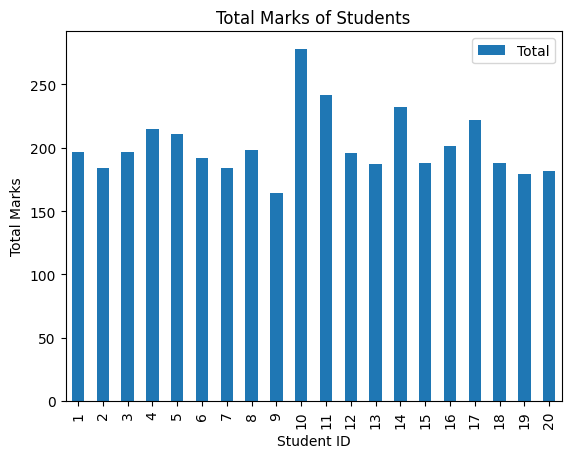

In [214]:

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("student_marks_dataset.csv")

# Basic info
print(df.head())
print(df.info())
print(df.describe())
print(df.shape)

# Remove duplicates
df = df.drop_duplicates()

# Create new columns
df['Total'] = df['Math'] + df['Science'] + df['English']
df['Average'] = df['Total'] / 3

# Grade function
def grade(avg):
    if avg >= 85:
        return "A"
    elif avg >= 70:
        return "B"
    elif avg >= 50:
        return "C"
    else:
        return "D"

df['Grade'] = df['Average'].apply(grade)

# Performance function
def performance(avg):
    if avg >= 85:
        return "Excellent"
    elif avg >= 70:
        return "Good"
    elif avg >= 50:
        return "Average"
    else:
        return "Poor"

df['Performance'] = df['Average'].apply(performance)

# Statistics
print("Average Marks:\n", df.mean(numeric_only=True))
print("Highest Marks:\n", df.max(numeric_only=True))
print("Lowest Marks:\n", df.min(numeric_only=True))

# Top & Weak students
top = df.nlargest(3, 'Average')
low = df.nsmallest(3, 'Average')

print("Top Students:\n", top[['Name', 'Average']])
print("Weak Students:\n", low[['Name', 'Average']])

print(df[['Math', 'Science', 'English']].corr())

# Visualization
df.plot(x='Student_ID', y='Total', kind='bar')
plt.title("Total Marks of Students")
plt.xlabel("Student ID")
plt.ylabel("Total Marks")
plt.savefig("output.png")
plt.show()